# Lab 10: Convolutional Neural Network (CNN)
## Objective
Design and implement a Convolutional Neural Network (CNN) model and evaluate its performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

**Note:** Since the Seeds dataset is tabular (not image data), we reshape each sample's 7 features into a 1D structure suitable for 1D convolutional operations. This demonstrates how CNNs can also be applied to structured/tabular data.

**Framework:** PyTorch

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0


## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols].values
y = df['Class'].values

# Encode labels (1,2,3) → (0,1,2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training: 168 samples
Testing:  42 samples
Features: 7


### 2.1 Reshape for CNN (1D Convolution)
For 1D CNN, we need input shape: `(batch, channels, length)`
- channels = 1 (single channel)
- length = 7 (number of features)

In [3]:
# Reshape: (samples, features) → (samples, 1, features)
X_train_cnn = X_train.reshape(-1, 1, X_train.shape[1])
X_test_cnn = X_test.reshape(-1, 1, X_test.shape[1])

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_cnn).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_cnn).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Input shape (CNN): {X_train_cnn.shape}")
print(f"  → (batch_size, channels=1, seq_length=7)")

Input shape (CNN): (168, 1, 7)
  → (batch_size, channels=1, seq_length=7)


## 3. Define CNN Architecture

In [4]:
class SeedClassifierCNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(SeedClassifierCNN, self).__init__()
        
        # Convolutional layers
        self.conv_block = nn.Sequential(
            # Conv Layer 1: 1 channel → 32 channels
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Conv Layer 2: 32 → 64 channels
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Conv Layer 3: 64 → 128 channels
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            # Global Average Pooling
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Fully connected layers
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

# Initialize model
num_features = X_train.shape[1]
num_classes = 3

model = SeedClassifierCNN(num_features, num_classes).to(device)
print("CNN Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

CNN Architecture:
SeedClassifierCNN(
  (conv_block): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=1)
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=32, out_features=3, bias=True)
  )
)

T

### 3.1 Verify Forward Pass

In [5]:
# Test with a sample batch
sample_input = torch.randn(4, 1, 7).to(device)  # batch=4, channels=1, seq=7
sample_output = model(sample_input)
print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Output: {sample_output.detach().cpu().numpy()}")

Input shape:  torch.Size([4, 1, 7])
Output shape: torch.Size([4, 3])
Output: [[ 0.12222048  0.2281744  -0.0822686 ]
 [ 0.10049845  0.14668874 -0.05723346]
 [ 0.09012416  0.19219144 -0.06999457]
 [ 0.09117387  0.20643362 -0.00231556]]


## 4. Define Loss and Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print(f"Loss Function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)")

Loss Function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)


## 5. Train the CNN

In [7]:
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
best_test_acc = 0.0

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluation
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = test_loss / len(test_loader)
    test_acc = correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
    
    scheduler.step(test_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

print(f"\n✅ Training complete!")
print(f"Best Test Accuracy: {best_test_acc:.4f} (Epoch {best_epoch})")
print(f"Final Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Test Accuracy:  {test_accuracies[-1]:.4f}")

Epoch [20/100] Train Loss: 0.2290, Train Acc: 0.9048 | Test Loss: 0.2533, Test Acc: 0.8810


Epoch [40/100] Train Loss: 0.1015, Train Acc: 0.9702 | Test Loss: 0.2390, Test Acc: 0.9286


Epoch [60/100] Train Loss: 0.0389, Train Acc: 0.9821 | Test Loss: 0.1796, Test Acc: 0.9524


Epoch [80/100] Train Loss: 0.0597, Train Acc: 0.9762 | Test Loss: 0.1811, Test Acc: 0.9524


Epoch [100/100] Train Loss: 0.0364, Train Acc: 0.9881 | Test Loss: 0.1981, Test Acc: 0.9524

✅ Training complete!
Best Test Accuracy: 0.9524 (Epoch 25)
Final Train Accuracy: 0.9881
Final Test Accuracy:  0.9524


## 6. Training History

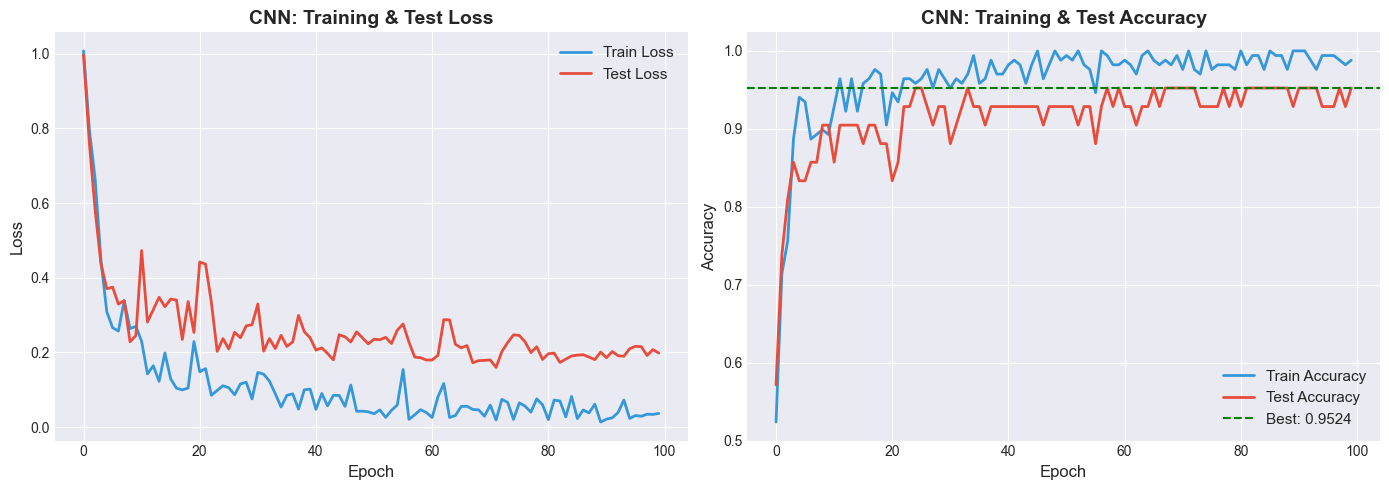

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('CNN: Training & Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Accuracy
axes[1].plot(train_accuracies, label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(test_accuracies, label='Test Accuracy', color='#e74c3c', linewidth=2)
axes[1].axhline(y=best_test_acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Best: {best_test_acc:.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('CNN: Training & Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 7. Evaluate the CNN

In [9]:
# Final evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, y_pred = torch.max(outputs, 1)
    y_pred = y_pred.cpu().numpy()
    y_true = y_test

class_names = ['Kama', 'Rosa', 'Canadian']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("CNN — Evaluation Metrics")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

CNN — Evaluation Metrics
Accuracy:  0.9524
Precision: 0.9556
Recall:    0.9524
F1 Score:  0.9514

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.86      0.92        14
        Rosa       0.93      1.00      0.97        14
    Canadian       0.93      1.00      0.97        14

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42



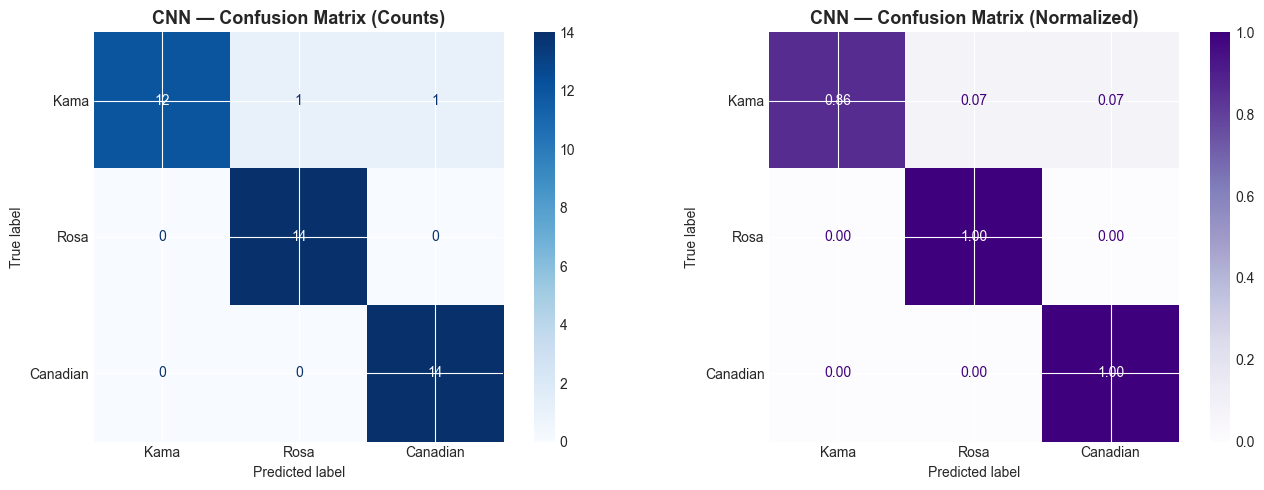

In [10]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('CNN — Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap='Purples', ax=axes[1], values_format='.2f')
axes[1].set_title('CNN — Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Feature Map Visualization

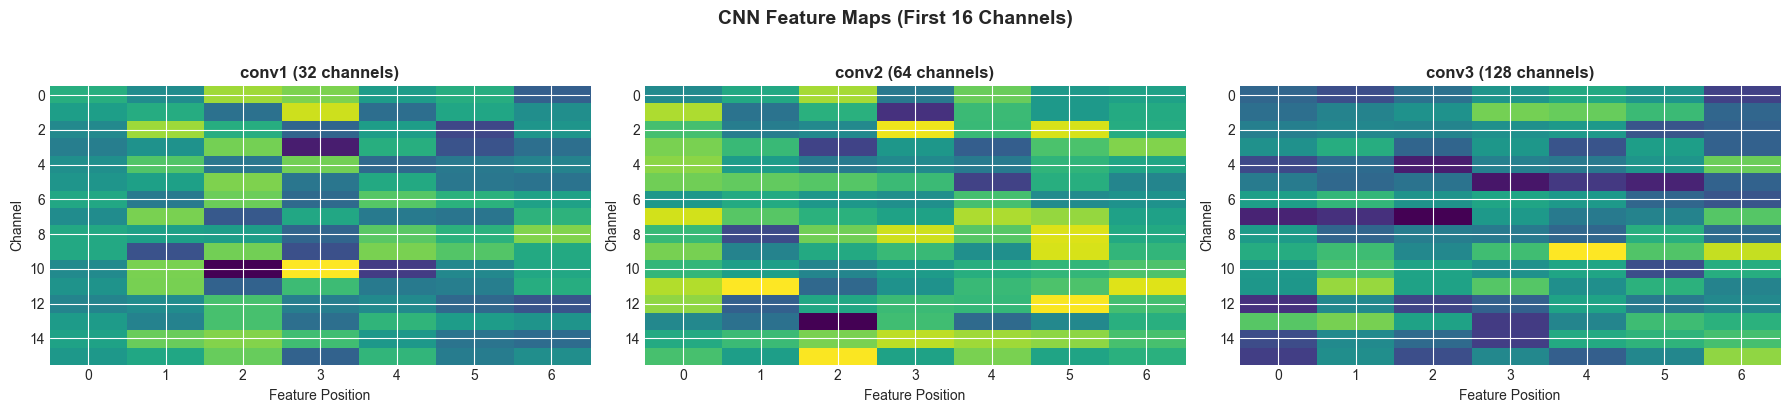

In [11]:
# Extract feature maps from convolutional layers
model.eval()

# Hook to capture intermediate outputs
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks
model.conv_block[0].register_forward_hook(get_activation('conv1'))
model.conv_block[3].register_forward_hook(get_activation('conv2'))
model.conv_block[6].register_forward_hook(get_activation('conv3'))

# Forward pass with one sample
with torch.no_grad():
    sample = X_test_tensor[0:1]
    _ = model(sample)

# Visualize feature maps
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, (name, act) in enumerate(activations.items()):
    act_np = act.cpu().numpy()[0]  # (channels, length)
    axes[i].imshow(act_np[:16], aspect='auto', cmap='viridis')  # Show first 16 channels
    axes[i].set_title(f'{name} ({act_np.shape[0]} channels)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Feature Position')
    axes[i].set_ylabel('Channel')

plt.suptitle('CNN Feature Maps (First 16 Channels)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. ANN vs CNN Comparison

In [12]:
# Train a simple ANN for comparison
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )
    
    def forward(self, x):
        return self.network(x)

ann_model = SimpleANN().to(device)
ann_optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

# ANN input (no reshape needed)
X_train_ann = torch.FloatTensor(X_train).to(device)
X_test_ann = torch.FloatTensor(X_test).to(device)

ann_dataset = TensorDataset(X_train_ann, y_train_tensor)
ann_loader = DataLoader(ann_dataset, batch_size=16, shuffle=True)

# Train ANN
ann_model.train()
for epoch in range(100):
    for inputs, labels in ann_loader:
        ann_optimizer.zero_grad()
        out = ann_model(inputs)
        loss = criterion(out, labels)
        loss.backward()
        ann_optimizer.step()

# Evaluate ANN
ann_model.eval()
with torch.no_grad():
    ann_out = ann_model(X_test_ann)
    _, ann_pred = torch.max(ann_out, 1)
    ann_pred = ann_pred.cpu().numpy()

ann_acc = accuracy_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred, average='weighted')

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Total Parameters'],
    'ANN': [ann_acc, ann_f1, sum(p.numel() for p in ann_model.parameters())],
    'CNN': [accuracy, f1, total_params]
})

print("ANN vs CNN Comparison")
print("=" * 50)
comparison

ANN vs CNN Comparison


,Metric,ANN,CNN
0,Accuracy,0.880952,0.952381
1,F1 Score,0.873056,0.951370
2,Total Parameters,2691.000000,41923.000000


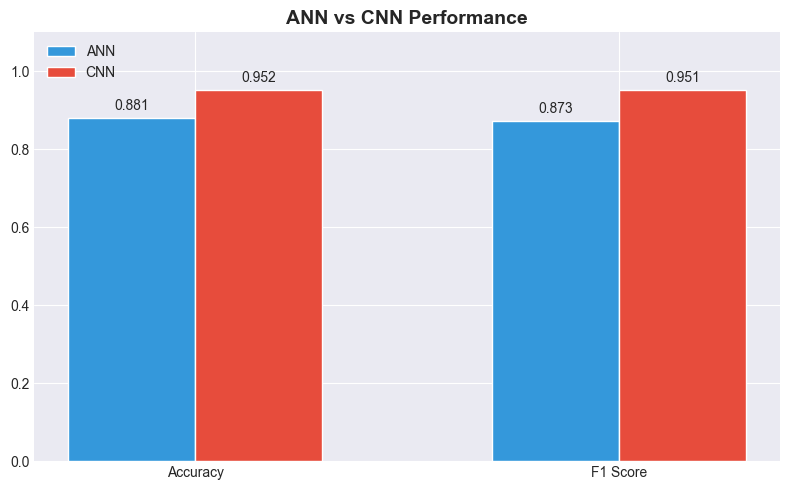

In [13]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.3

ax.bar(x - width/2, [ann_acc, ann_f1], width, label='ANN', color='#3498db', edgecolor='white')
ax.bar(x + width/2, [accuracy, f1], width, label='CNN', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'])
ax.set_ylim(0, 1.1)
ax.set_title('ANN vs CNN Performance', fontsize=14, fontweight='bold')
ax.legend()

# Add value labels
for i, (v1, v2) in enumerate(zip([ann_acc, ann_f1], [accuracy, f1])):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Model Summary

In [14]:
print("=" * 60)
print("CNN MODEL SUMMARY")
print("=" * 60)
print(f"\nArchitecture:")
print(f"  Conv1d: 1 → 32 channels (kernel=3, padding=1) + BN + ReLU")
print(f"  Conv1d: 32 → 64 channels (kernel=3, padding=1) + BN + ReLU")
print(f"  Conv1d: 64 → 128 channels (kernel=3, padding=1) + BN + ReLU")
print(f"  AdaptiveAvgPool1d → 1")
print(f"  FC: 128 → 64 → 32 → 3")
print(f"\nInput:  (batch, 1, 7) — 1D conv over 7 features")
print(f"Output: (batch, 3) — 3 wheat variety classes")
print(f"\nTotal parameters:     {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"\nTest Accuracy:  {accuracy:.4f}")
print(f"Test F1 Score:  {f1:.4f}")

CNN MODEL SUMMARY

Architecture:
  Conv1d: 1 → 32 channels (kernel=3, padding=1) + BN + ReLU
  Conv1d: 32 → 64 channels (kernel=3, padding=1) + BN + ReLU
  Conv1d: 64 → 128 channels (kernel=3, padding=1) + BN + ReLU
  AdaptiveAvgPool1d → 1
  FC: 128 → 64 → 32 → 3

Input:  (batch, 1, 7) — 1D conv over 7 features
Output: (batch, 3) — 3 wheat variety classes

Total parameters:     41923
Trainable parameters: 41923

Test Accuracy:  0.9524
Test F1 Score:  0.9514


## 11. Conclusion
In this lab, we:
- Designed a **1D CNN** using PyTorch for tabular classification
- Used **3 convolutional layers** with BatchNorm, ReLU, and Global Average Pooling
- Added **fully connected layers** with Dropout for classification
- Visualized **feature maps** from convolutional layers
- Compared **ANN vs CNN** performance on the same dataset
- Both architectures achieve strong results — CNNs can extract local patterns even in tabular data
- For tabular data, ANN may be more efficient; CNNs shine on image/sequential data